In [ ]:
import numpy as np
import pandas as pd
import pickle as pkl

In [3]:
pd.__version__

'2.3.3'

In [4]:
import pandas as pd
print(pd.__version__)


2.3.3


In [ ]:
chunk_metadata=pd.read_pickle(r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\phase_2_chunk_metadata.pkl")

In [ ]:
user_embeddings= pd.read_pickle(r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\phase_2_user_emb.pkl")

In [7]:
item_emb_df=pd.DataFrame(pd.read_pickle(r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\phase_2_item_emb.pkl"))

In [8]:
item_emb_df ## item_emb corresponding to chunk_metadata

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,0.005983,-0.114306,0.010787,0.013902,0.033052,-0.035159,0.001696,-0.002761,-0.159066,6.712158e-02,...,0.122445,0.056867,0.015835,-0.095521,-0.017067,0.039663,0.001824,0.018260,0.024497,0.049461
1,0.018841,-0.049462,-0.019324,0.047654,-0.030958,-0.132104,-0.010963,-0.022627,-0.104423,7.471888e-02,...,0.076173,0.059800,-0.013842,-0.015980,-0.063965,0.043082,0.016098,-0.015716,0.018855,0.017013
2,-0.034618,-0.012705,-0.009682,0.047390,-0.045320,-0.134024,-0.003128,0.022114,-0.095068,7.450934e-02,...,0.087518,0.066692,-0.054004,0.044697,-0.064051,0.010807,0.019182,0.034702,0.044463,0.004105
3,0.009912,-0.084497,0.009273,-0.009979,0.007115,-0.015803,0.008705,-0.030429,-0.014096,2.075856e-02,...,0.082581,-0.003411,0.063104,-0.090111,0.013327,0.111447,0.068637,-0.040063,0.059502,0.052815
4,-0.057536,-0.070677,0.072725,-0.012639,-0.055164,-0.054520,-0.038707,0.023866,-0.129048,-5.992439e-02,...,0.055993,0.021843,0.013714,-0.114427,-0.029592,0.059157,-0.040263,0.052765,0.028108,0.044863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14556,-0.102176,0.003083,-0.050815,-0.009713,-0.004004,-0.042375,-0.042589,-0.008008,0.058870,9.889977e-03,...,0.067131,0.128255,0.014666,-0.000209,-0.010557,0.000473,-0.008513,0.004577,-0.061755,-0.077331
14557,-0.041736,-0.045683,0.018611,-0.063583,-0.093122,0.015551,-0.013019,-0.012797,-0.100758,-7.014660e-02,...,-0.031689,-0.067450,0.006950,0.004497,0.102326,-0.006385,0.080737,0.011633,-0.035397,0.010775
14558,-0.039387,0.060689,-0.010403,-0.019768,0.012824,0.003527,0.066864,-0.023271,0.008612,-4.557156e-02,...,-0.006619,0.031710,-0.038147,0.015515,-0.042890,-0.034630,0.044189,-0.078445,-0.074800,0.028106
14559,-0.138386,0.002937,-0.086947,0.040883,0.021222,0.076411,0.052605,0.005755,0.036329,-8.086116e-08,...,0.028251,0.093383,0.053800,0.001946,-0.087360,0.037808,0.030206,0.010560,-0.004265,0.001004


In [9]:
df1=pd.read_pickle(r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\phase_2_item.pkl")

In [10]:
from sentence_transformers import SentenceTransformer
import torch
target_domains = [
    "Movie",
    "TV Series",
    "Documentary",
    "Courses"
]
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')
target_emb = model_sbert.encode(target_domains, convert_to_tensor=True)
def map_domain_sbert(domain):
    
    if domain is None or str(domain) == "<NA>":
        return "Other"

    domain = str(domain).lower()

    emb = model_sbert.encode(domain, convert_to_tensor=True)

    scores = torch.matmul(emb, target_emb.T)

    best_idx = torch.argmax(scores).item()

    return target_domains[best_idx]
df1['normalized_domain'] = df1['combined'].apply(map_domain_sbert)

c:\Users\nihal\torch_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7054.43it/s]


In [11]:
df1.drop(columns=['combined'],inplace=True)

In [12]:
df1.head(5)

,title,domain,metadata,movie_id,normalized_domain
0,machine learning specialization,Machine Learning,"Decision Trees, Artificial Neural Network, Log...",n0,Courses
1,introduction to data science specialization,Data Analysis,"Data Science, Relational Database Management S...",n1,Courses
2,data science fundamentals with python and sql ...,Data Analysis,"Data Science, Github, Python Programming, Jupy...",n2,Courses
3,key technologies for business specialization,Business Essentials,"Data Science, Artificial Intelligence (AI), Bu...",n3,Courses
4,deep learning specialization,Machine Learning,"Artificial Neural Network, Convolutional Neura...",n4,Courses


In [13]:

import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
class RecommenderModel(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        input_dim = emb_dim * 3  # user + item + interaction

        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.LayerNorm(256),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(self, user, item):
        interaction = user * item  # element-wise
        x = torch.cat([user, item, interaction], dim=1)
        return self.model(x)

In [16]:
import torch.nn.functional as F

# ---------------- BPR LOSS ----------------
def bpr_loss(pos_scores, neg_scores):
    return -torch.mean(F.logsigmoid(pos_scores - neg_scores))

In [17]:
model = RecommenderModel(emb_dim=384).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [18]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print(next(model.parameters()).device)

CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
cuda:0


In [19]:
movie_to_domain = dict(zip(df1['movie_id'], df1['normalized_domain']))
index_to_domain = {
    idx: movie_to_domain.get(chunk_metadata[idx]['id'], "Other")
    for idx in range(len(chunk_metadata))
}


In [20]:
def balance_training_data(df):
    
    domain_counts = df['normalized_domain'].value_counts()
    min_count = domain_counts.min()

    balanced = []

    for domain in domain_counts.index:
        subset = df[df['normalized_domain'] == domain].sample(min_count)
        balanced.append(subset)

    return pd.concat(balanced).reset_index(drop=True)

In [21]:
from collections import defaultdict

domain_to_indices = defaultdict(list)

for idx in range(len(item_emb_df)):

    movie_id = chunk_metadata[idx]['id']

    domain = movie_to_domain.get(movie_id, "Other")

    domain_to_indices[domain].append(idx)

In [ ]:
# import the model from phase-3,as it was pretarianed on the data before

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RecommenderModel(emb_dim=384).to(device)   # or input_dim=768 (based on your model)
model.load_state_dict(
    torch.load(
        r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\phase_3_model_2.pt",
        map_location=device
    )
)
model.eval()

C:\Users\nihal\AppData\Local\Temp\ipykernel_30560\3275728801.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


RecommenderModel(
  (model): Sequential(
    (0): Linear(in_features=1152, out_features=512, bias=True)
    (1): ReLU()
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [24]:
user_movie_list=[]
for i in range(1, 5001):

    df = pd.DataFrame(pd.read_pickle(r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\user\phase_2_user_part_{}.pkl".format(i)))
    df = df[[0, 3, 8]]  # 0-->user_id 3--->movie_id 8--->embeddings
    df.rename(columns={0: 'user_id', 3: 'movie_id', 8: 'embedding'}, inplace=True)
    
    for _, row in df.iterrows():
        user_id, movie_id, item_emb = row
        if user_id in user_embeddings:
            user_movie_list.append({
            'user_id': user_id,
            'movie_id': movie_id
                })
user_movie=pd.DataFrame(user_movie_list)
del user_movie_list

In [ ]:
# Two-stage recommender architecture

In [26]:
user_id="user_02660"

# -------- USER --------
user_vec = user_embeddings[user_id].reshape(1, -1)
user_vec_t = torch.tensor(user_vec, dtype=torch.float32).to(device)

# -------- RETRIEVAL --------
sim_scores = torch.matmul(user_vec_t, item_tensor.T)[0]
candidate_indices = torch.topk(sim_scores, k=100).indices.cpu().numpy()

# -------- REMOVE SEEN --------
seen_items = set(
    user_movie[user_movie['user_id'] == user_id]['movie_id'].values
)

candidate_indices = [
    idx for idx in candidate_indices
    if chunk_metadata[idx]['id'] not in seen_items
]
user_vec = user_embeddings[user_id].reshape(1, -1)

item_mat = item_emb_df.iloc[candidate_indices].values

user_t = torch.tensor(user_vec, dtype=torch.float32).to(device)
item_t = torch.tensor(item_mat, dtype=torch.float32).to(device)

# repeat user for all items
user_t = user_t.repeat(item_t.shape[0], 1)

model.eval()
with torch.no_grad():
    scores = model(user_t, item_t).cpu().numpy().flatten()

# -------- TOP-K --------
top_k = 10
top_indices = np.argsort(scores)[-top_k:][::-1]

final_indices = [candidate_indices[i] for i in top_indices]

# -------- MAP IDS --------
final_ids = [chunk_metadata[idx]['id'] for idx in final_indices]

# -------- BUILD RESULT (ORDER PRESERVED) --------
id_score_map = dict(zip(final_ids, scores[top_indices]))

results = df1[df1['movie_id'].isin(final_ids)].copy()
results["score"] = results["movie_id"].map(id_score_map)

results = results.sort_values("score", ascending=False).reset_index(drop=True)

print(results.head(10))

            title       domain          metadata    movie_id  \
0  family kingdom        Movie         Adventure  movie_0840   
1      city queen  Documentary            Family  movie_0043   
2   family legend        Movie      Family Sport  movie_0451   
3    family story    TV Series               War  movie_0404   
4     family king        Movie               War  movie_0931   
5  family mystery    TV Series        War Family  movie_0822   
6   secret family        Movie  Thriller Fantasy  movie_0445   
7           a day        Movie            Family  movie_0712   
8   secret legend        Movie            Family  movie_0048   
9         big ice  Documentary  Family Adventure  movie_0369   

  normalized_domain      score  
0             Movie -14.052860  
1       Documentary -14.277094  
2             Movie -14.286934  
3         TV Series -14.558565  
4             Movie -14.631669  
5         TV Series -14.804883  
6             Movie -14.944227  
7             Movie -15.051851 

In [ ]:
#User Embedding
#↓
#Candidate Retrieval (SBERT similarity)
#↓
#Remove Seen Items
#↓
#BPR Neural Ranking
#↓
#Top-K Recommendations
# this flow is for phase-3 

In [ ]:
# phase-4 as Ranking model ≠ whole recommender system so we need to make better flow ,we need to genralize the recoomendation 
# not only his intrest we need to give outside of his intrest 

In [ ]:
# phase -3 to phase -4
#Retrieval           
#↓
#BPR Ranking
#↓
#Top-K
 
 
 # the flow has been genrailzed between both phases
 
 
#Retrieval
#↓
#BPR Ranking
#↓
#MMR Diversity  Soft-Penalty Reranking
#↓
#Domain Balancing
#↓
#Exploration
#↓
#Final Feed

In [ ]:
# dataframe for all the items seen by this particular user
frames = [df1[df1['movie_id'] == i] for i in seen_items]
ans = pd.concat(frames, ignore_index=True)
ans

,title,domain,metadata,movie_id,normalized_domain
0,city quest,Documentary,Drama,movie_0575,Documentary
1,mission dream,Movie,Biography,movie_0057,Movie
2,family mission,Movie,Documentary,movie_0189,Documentary
3,our legend,Movie,War,movie_0836,Movie
4,new story,Movie,Horror,movie_0537,Movie
5,queenmission,TV Series,Adventure,movie_0446,TV Series
6,quest house,Movie,Action,movie_0472,Movie
7,old house,TV Series,Comedy,movie_0186,TV Series
8,princess city,TV Series,Animation,movie_0871,TV Series
9,house war,Movie,Sci-Fi,movie_0300,Movie


In [ ]:
# STEP 1 — MMR RERANKING

#Goal:
#
#reduce repetition
#increase diversity
#
#We will improve:
#
#diversity quality
#MMR efficiency
#score handling
#redundancy filtering
# as data is with lack of diversity so as mmr reranking for relevance + diversity
# we will add slow penalty in mmr as we need penalize the items of same kind so that all the reccomendations are not belong ot sam etype which makes it not good.

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def mmr_selection(candidate_indices, scores, item_embeddings, top_k=10, lambda_param=0.7,
    duplicate_threshold=0.95):
    
    selected = []
    # fast score lookup
    score_map = {
        idx: score
        for idx, score in zip(candidate_indices, scores)
    }
    candidates = list(candidate_indices)

    while len(selected) < top_k and candidates:

        mmr_scores = []

        for idx in candidates:
            relevance = score_map[idx]

            if not selected:
                diversity_penalty = 0
            else:
                similarities = [
                    cosine_similarity(
                        item_embeddings[idx].reshape(1, -1),
                        item_embeddings[s].reshape(1, -1)
                    )[0][0]
                    for s in selected
                ]
                max_sim=max(similarities)
                if max_sim>=duplicate_threshold:
                    continue
                #Purpose:Removes:near-identical recommendations,repetitive titles/themes
                # keeping same kind oftwo movies is better to remove one of them for better diversity.
                     
                diversity_penalty=max_sim
                
            # -------- SOFT PENALTY --------
            mmr_score = (
                lambda_param * relevance
                -
                (1 - lambda_param) * diversity_penalty
            )

            mmr_scores.append((idx, mmr_score))

        # if no candidates left
        if not mmr_scores:
            break

        # best reranked item
        best = max(mmr_scores, key=lambda x: x[1])[0]

        selected.append(best)
        candidates.remove(best)

    return selected

In [ ]:
user_id="user_02660"

# -------- USER --------
user_vec = user_embeddings[user_id].reshape(1, -1)
user_vec_t = torch.tensor(user_vec, dtype=torch.float32).to(device)


# -------- RETRIEVAL --------
sim_scores = torch.matmul(user_vec_t, item_tensor.T)[0]
candidate_indices = torch.topk(sim_scores, k=100).indices.cpu().numpy()

# -------- REMOVE Seen items --------
seen_items = set(
    user_movie[user_movie['user_id'] == user_id]['movie_id'].values
)

candidate_indices = [
    idx for idx in candidate_indices
    if chunk_metadata[idx]['id'] not in seen_items
]
user_vec = user_embeddings[user_id].reshape(1, -1)

item_mat = item_emb_df.iloc[candidate_indices].values

user_t = torch.tensor(user_vec, dtype=torch.float32).to(device)
item_t = torch.tensor(item_mat, dtype=torch.float32).to(device)

# repeat user for all items
user_t = user_t.repeat(item_t.shape[0], 1)

model.eval()

with torch.no_grad():
    scores = model(user_t, item_t).cpu().numpy().flatten()


final_indices = mmr_selection(
    candidate_indices,
    scores,
    item_emb_df.values,
    top_k=10,
    lambda_param=0.75
)

# -------- MAP IDS --------
final_ids = [chunk_metadata[idx]['id'] for idx in final_indices]

selected_scores = [
    scores[list(candidate_indices).index(idx)]
    for idx in final_indices
]

id_score_map = dict(zip(final_ids, selected_scores))

results = df1[df1['movie_id'].isin(final_ids)].copy()
results["score"] = results["movie_id"].map(id_score_map)

results = results.sort_values("score", ascending=False).reset_index(drop=True)

print(results.head(10))

            title       domain          metadata    movie_id  \
0  family kingdom        Movie         Adventure  movie_0840   
1      city queen  Documentary            Family  movie_0043   
2   family legend        Movie      Family Sport  movie_0451   
3    family story    TV Series               War  movie_0404   
4     family king        Movie               War  movie_0931   
5  family mystery    TV Series        War Family  movie_0822   
6   secret family        Movie  Thriller Fantasy  movie_0445   
7           a day        Movie            Family  movie_0712   
8         big ice  Documentary  Family Adventure  movie_0369   
9   mission quest        Movie       Documentary  movie_0340   

  normalized_domain      score  
0             Movie -14.052860  
1       Documentary -14.277094  
2             Movie -14.286934  
3         TV Series -14.558565  
4             Movie -14.631669  
5         TV Series -14.804883  
6             Movie -14.944227  
7             Movie -15.051851 

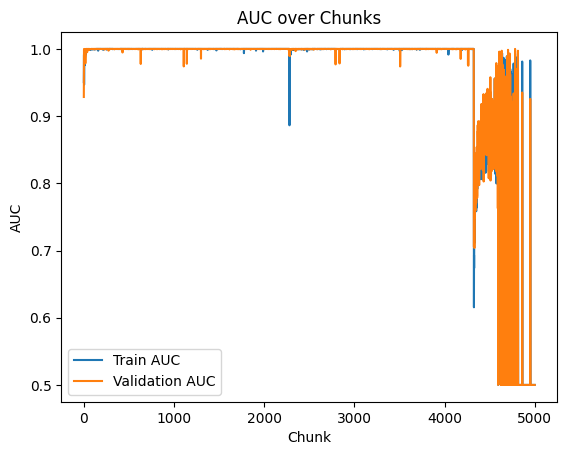

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_auc_list, label='Train AUC')
plt.plot(val_auc_list, label='Validation AUC')

plt.xlabel("Chunk")
plt.ylabel("AUC")
plt.title("AUC over Chunks")
plt.legend()

plt.show()

In [ ]:
# as you can see the AUC graph where it is mostly stable upto 2300 iteration then it is getting fluctiuating but there is point that the both train and test 
# AUC are moving in one direction with each other.

In [ ]:
# as it is lack of domain ,all are similar are to each othe rin MMR selection 
# We need to adjust 
# lambda and duplicate score in mmr_selction for better rejection and selection 
# also increse value of k so that you will have better option in choosing different kind of items.Slect 100 or 1000 and out of it take 10 or 20

In [30]:
dom=set(df1['domain'].str.lower())

In [31]:
print(dom)

{'psychology', 'data management', 'business strategy', 'operations and support', 'patient care', 'basic science', 'algorithms', 'entrepreneurship', 'philosophy', 'networking', 'cloud computing', 'research methods', 'health informatics', 'engineering', 'law', 'electrical engineering', 'animal health', 'computer science', 'tv series', 'other languages', 'public health', 'limited series', 'renewable energy', 'finance', 'learning english', 'healthcare management', 'software development', 'support and operations', 'research', 'biochemistry', 'probability and statistics', 'data analysis', 'physics', 'movie', 'music and art', 'computer security and networks', 'machine learning', '移动和网络开发', 'stand-up comedy', 'personal development', 'security', 'education', 'design and product', 'physics and astronomy', 'biology', 'economics', 'math and logic', 'mechanical engineering', 'tv show', 'mobile and web development', 'nutrition', 'environmental science and sustainability', 'leadership and management'

In [ ]:
# As i have these many feilds so ,i need to refine them into 4 subfeilds,as genaralized category so that it becomes easy to seggereagate.

In [32]:
df1.sample(5)

,title,domain,metadata,movie_id,normalized_domain
10676,Spirit: Riding Free,TV Show,"Kids' TV In a small Western town, spunky ex-ci...",s5761,TV Series
4524,let’s learn thai language: basic conversation ...,<NA>,Take your understanding of Thailand and its c...,n6614,Courses
6313,Citation,Movie,"Dramas, International Movies A bright student ...",s1398,Movie
9875,Prank Encounters,TV Show,"Reality TV, TV Comedies, TV Horror Monstrous f...",s4960,TV Series
2512,bioconductor for genomic data science,Data Analysis,"Bioinformatics,Bioconductor,Genomics,R Program...",n2751,Courses


In [33]:
domain_map = {
    idx: df1.loc[df1['movie_id'] == chunk_metadata[idx]['id'], 'normalized_domain'].values[0]
    for idx in range(len(chunk_metadata))
}


In [38]:
print(domain_map[10000])

TV Series


In [49]:
item_emb_matrix = item_emb_df.values.astype(np.float32)

norms = np.linalg.norm(item_emb_matrix, axis=1, keepdims=True)

item_emb_matrix = item_emb_matrix / (norms + 1e-8)
item_tensor = torch.tensor(
    item_emb_matrix,
    dtype=torch.float32
).to(device)

In [50]:
def mmr_selection(candidate_indices, scores, item_embeddings, top_k=100, lambda_param=0.55,
    duplicate_threshold=0.65):
    
    selected = []
    # fast score lookup
    score_map = {
        idx: score
        for idx, score in zip(candidate_indices, scores)
    }
    candidates = list(candidate_indices)

    while len(selected) < top_k and candidates:

        mmr_scores = []

        for idx in candidates:
            relevance = score_map[idx]

            if not selected:
                diversity_penalty = 0
            else:
                similarities = [
    np.dot(item_embeddings[idx], item_embeddings[s])
    for s in selected
]
                max_sim=max(similarities)
                if max_sim>=duplicate_threshold:
                    continue
                #Purpose:Removes:near-identical recommendations,repetitive titles/themes
                # keeping same kind oftwo movies is better to remove one of them for better diversity.
                     
                diversity_penalty=max_sim
                
            # -------- SOFT PENALTY --------
            mmr_score = (
                lambda_param * relevance
                -
                (1 - lambda_param) * diversity_penalty
            )

            mmr_scores.append((idx, mmr_score))

        # no candidates left
        if not mmr_scores:
            break

        # best reranked item
        best = max(mmr_scores, key=lambda x: x[1])[0]

        selected.append(best)
        candidates.remove(best)

    return selected

In [51]:
def domain_balanced_selection(
    indices,
    domain_map,
    top_k=10
):

    # quotas must sum close to top_k
    domain_quota = {
        "Movie": 4,
        "TV Series": 2,
        "Documentary": 2,
        "Courses": 2
    }

    selected = []

    # preserve MMR ordering
    for idx in indices:

        domain = domain_map.get(idx, "Other")

        if domain_quota.get(domain, 0) > 0:

            selected.append(idx)

            domain_quota[domain] -= 1

        if len(selected) >= top_k:
            break

    # fallback
    if len(selected) < top_k:

        for idx in indices:

            if idx not in selected:
                selected.append(idx)

            if len(selected) >= top_k:
                break

    return selected

In [ ]:
user_id="user_02660"

# -------- USER --------
# normalize user embedding
user_vec = user_vec / (
    np.linalg.norm(user_vec, axis=1, keepdims=True) + 1e-8
)

user_vec_t = torch.tensor(
    user_vec,
    dtype=torch.float32
).to(device)


# get top 1000 so that it will become safe 
sim_scores = torch.matmul(user_vec_t, item_tensor.T)[0]
candidate_indices = torch.topk(sim_scores, k=1000).indices.cpu().numpy()

# -------- REMOVE SEEN --------
seen_items = set(
    user_movie[user_movie['user_id'] == user_id]['movie_id'].values
)

candidate_indices = [
    idx for idx in candidate_indices
    if chunk_metadata[idx]['id'] not in seen_items
]
user_vec = user_embeddings[user_id].reshape(1, -1)

item_mat = item_emb_df.iloc[candidate_indices].values

user_t = torch.tensor(user_vec, dtype=torch.float32).to(device)
item_t = torch.tensor(item_mat, dtype=torch.float32).to(device)

# repeat user for all items
user_t = user_t.repeat(item_t.shape[0], 1)

model.eval()
with torch.no_grad():
    scores = model(user_t, item_t).cpu().numpy().flatten()

# -------- TOP-k--------

diverse_indices = mmr_selection(
    candidate_indices=candidate_indices,
    scores=scores,
    item_embeddings=item_emb_matrix,
    top_k=100,
    lambda_param=0.55,
    duplicate_threshold=0.75
)
score_map = {
    idx: score
    for idx, score in zip(candidate_indices, scores)
}

diverse_scores = [
    score_map[idx]
    for idx in diverse_indices
]
# Domain balancing
final_indices = domain_balanced_selection(
    diverse_indices,
   
    domain_map,
    top_k=10
)
#map ids to movie_ids
final_ids = [chunk_metadata[idx]['id'] for idx in final_indices]

final_scores = [
    score_map[idx]
    for idx in final_indices
]

id_score_map = dict(zip(final_ids, final_scores))

results = df1[df1['movie_id'].isin(final_ids)].copy()
results["score"] = results["movie_id"].map(id_score_map)

results = results.sort_values("score", ascending=False).reset_index(drop=True)
print(
    results[
        [
            'title',
            'domain',
            'metadata',
            'movie_id',
            'normalized_domain',
            'score'
        ]
    ].head(10)
)

            title       domain           metadata    movie_id  \
0    house family    TV Series             Action  movie_0073   
1   mystery house        Movie   Family Biography  movie_0827   
2      big family    TV Series          War Sport  movie_0534   
3   empire family        Movie  Biography Fantasy  movie_0989   
4     queen queen        Movie             Family  movie_0539   
5   day adventure        Movie           Thriller  movie_0935   
6        was fire        Movie      Comedy Family  movie_0843   
7     dark legend        Movie             Sci-Fi  movie_0568   
8     first house  Documentary                War  movie_0781   
9  journey empire    TV Series  Crime Documentary  movie_0964   

  normalized_domain      score  
0         TV Series -11.981762  
1         TV Series -12.012469  
2         TV Series -12.063503  
3             Movie -12.135022  
4             Movie -12.141310  
5             Movie -12.190060  
6             Movie -12.247476  
7             Movie 

CURRENT PROBLEM

Right now our system is:

fully exploitative(recommend only highest-confidence items)

Beacuse over time the system becomes:

too predictable
too repetitive
stick to one preference domain
but explaoration fixes this

After:

MMR + domain balancing

we will inject:

a few diverse lower-ranked items so that exploration i shandeled

In [ ]:
# add exploaration


In [54]:
import random

def inject_exploration(
    selected_indices,
    candidate_indices,
    score_map,
    top_k=10,
    explore_ratio=0.2
):

    # number of exploratory items
    n_explore = int(top_k * explore_ratio)

    if n_explore == 0:
        return selected_indices[:top_k]

    # keep top safe items
    safe_count = top_k - n_explore

    final_selected = selected_indices[:safe_count]

    # remaining pool
    remaining = [
        idx for idx in candidate_indices
        if idx not in final_selected
    ]

    # exploration pool:
    # moderately relevant items only
    remaining = sorted(
        remaining,
        key=lambda x: score_map[x],
        reverse=True
    )

    # avoid very bad items
    exploration_pool = remaining[20:100]

    if len(exploration_pool) > 0:

        explore_items = random.sample(
            exploration_pool,
            min(n_explore, len(exploration_pool))
        )

        final_selected.extend(explore_items)

    return final_selected[:top_k]

In [ ]:
user_id="user_02660"


# normalize user embedding
user_vec = user_vec / (
    np.linalg.norm(user_vec, axis=1, keepdims=True) + 1e-8
)

user_vec_t = torch.tensor(
    user_vec,
    dtype=torch.float32
).to(device)


sim_scores = torch.matmul(user_vec_t, item_tensor.T)[0]
candidate_indices = torch.topk(sim_scores, k=1000).indices.cpu().numpy()


seen_items = set(
    user_movie[user_movie['user_id'] == user_id]['movie_id'].values
)

candidate_indices = [
    idx for idx in candidate_indices
    if chunk_metadata[idx]['id'] not in seen_items
]
user_vec = user_embeddings[user_id].reshape(1, -1)

item_mat = item_emb_df.iloc[candidate_indices].values

user_t = torch.tensor(user_vec, dtype=torch.float32).to(device)
item_t = torch.tensor(item_mat, dtype=torch.float32).to(device)

# repeat user for all items
user_t = user_t.repeat(item_t.shape[0], 1)

model.eval()
with torch.no_grad():
    scores = model(user_t, item_t).cpu().numpy().flatten()


diverse_indices = mmr_selection(
    candidate_indices=candidate_indices,
    scores=scores,
    item_embeddings=item_emb_matrix,
    top_k=100,
    lambda_param=0.55,
    duplicate_threshold=0.75
)
score_map = {
    idx: score
    for idx, score in zip(candidate_indices, scores)
}

diverse_scores = [
    score_map[idx]
    for idx in diverse_indices
]
#Domain balancing
final_indices = domain_balanced_selection(
    diverse_indices,
    domain_map,
    top_k=20
)
final_indices = inject_exploration(
    selected_indices=final_indices,
    candidate_indices=diverse_indices,
    score_map=score_map,
    top_k=20,
    explore_ratio=0.2
)
# map ids to movie_ids
final_ids = [chunk_metadata[idx]['id'] for idx in final_indices]

final_scores = [
    score_map[idx]
    for idx in final_indices
]

id_score_map = dict(zip(final_ids, final_scores))

results = df1[df1['movie_id'].isin(final_ids)].copy()
results["score"] = results["movie_id"].map(id_score_map)

results = results.sort_values("score", ascending=False).reset_index(drop=True)
print(
    results[
        [
            'title',
            'domain',
            'metadata',
            'movie_id',
            'normalized_domain',
            'score'
        ]
    ].head(10)
)

                title     domain           metadata    movie_id  \
0        house family  TV Series             Action  movie_0073   
1       mystery house      Movie   Family Biography  movie_0827   
2          big family  TV Series          War Sport  movie_0534   
3       empire family      Movie  Biography Fantasy  movie_0989   
4         queen queen      Movie             Family  movie_0539   
5         night house      Movie             Horror  movie_0819   
6       day adventure      Movie           Thriller  movie_0935   
7  adventure princess      Movie             Family  movie_0133   
8          dark storm  TV Series             Family  movie_0276   
9            was fire      Movie      Comedy Family  movie_0843   

  normalized_domain      score  
0         TV Series -11.981762  
1         TV Series -12.012469  
2         TV Series -12.063503  
3             Movie -12.135022  
4             Movie -12.141310  
5             Movie -12.173446  
6             Movie -12.190060 

In [ ]:
# now add precison@ K evaluation,but you dont have data 


In [ ]:
# def precision_at_k(
#     recommended_ids,
#     relevant_ids,
#     k=10
# ):

#     recommended_k = recommended_ids[:k]

#     hits = len(
#         set(recommended_k) & set(relevant_ids)
#     )

#     return hits / k
# all_precisions = []

# for user_id in evaluation_users:

#     # generate recommendations
#     recommended_ids = ...

#     # hidden true items
#     relevant_ids = ...

#     p = precision_at_k(
#         recommended_ids,
#         relevant_ids,
#         k=10
#     )

#     all_precisions.append(p)

# mean_precision = np.mean(all_precisions)

# print("Mean Precision@10:", mean_precision)